# Plot options for impact ensemble forecasts

This snippet provides some suggestions and code for how to plot CLIMADA impact forecasts including several ensemble members. As an example, we use current wind speed forecasts by MeteoSwiss, provided in the [open government data](https://www.meteoschweiz.admin.ch/service-und-publikationen/service/open-data.html) API, see [github](https://github.com/MeteoSwiss/meteodata-lab) and [demos](https://github.com/MeteoSwiss/opendata-nwp-demos/blob/main/01_retrieve_process_precip.ipynb). We then create a forecast of damaged buildings based on the methodology of [Röösli et al., 2020](https://doi.org/10.1002/met.2035), and produce several forecast products as exemplified in the [wind damage demonstrator website WiSchWa](https://data.iac.ethz.ch/WCR_sandbox/WiSchaWa).

### Table of Contents
1. [Aggregation helper functions](#1-aggregation-helper-functions)
2. [Impact forecasts](#2-impact-forecasts)
    - 2.1 [Download hazard forecast data](#21-download-hazard-forecast-data)
    - 2.2 [Prepare exposure data](#22-prepare-expsore-data)
    - 2.3 [Define impact functions](#23-define-impact-functions)
    - 2.4 [Compute impact forecasts](#24-compute-impact-forecasts)
3. [Plot a spatially-aggregated histogram](#3-plot-a-spatially-aggregated-histogram)
4. [Plot a regional pie-chart map](#4-plot-a-regional-pie-chart-map)
5. [Plot threshold-based warnings](#5-plot-threshold-based-warnings)

### Package and data requirements
1. To use CLIMADA forecast classes, you need an environement with a CLIMADA version >= 7.0.0.
2. To use the **MeteoSwiss open government data**, you need to install the package `meteodata-lab` in your CLIMADA environement. In your environment, use 
    ```console
    pip install meteodata-lab
    ```
3. To aggregate the impact forecast to spatial regions, you must provide a gpd.GeoDataFrame containing the geometries of the regions. Below, we use the geometries of the Swiss cantons, availale as downloads in the dataset [swissTLMregio](https://www.swisstopo.admin.ch/de/landschaftsmodell-swisstlmregio) by SwissTopo. The path `path_to_canton_shapes` defined below must contain the path to the shape files (.shp) containing the canton borders, e.g.: "swissTLMRegio_KANTONSGEBIET_LV95.shp"
4. To create warning maps, you must provide a gpd.GeoDataFrame containing the geometries of the warning regions. Below, we use the geometries of the warning regions as used by MeteoSwiss, available upon request (including indicated purpose) at [MeteoSwiss Services](https://www.meteoswiss.admin.ch/services-and-publications/service.html). The `path_to_warningregion_shapes` defined below must contain the path to the shape files (.shp) containing the warning regions
5. The MeteoSwiss wind warnings depend on wind speed thresholds depending on altitute. Thus, CLIMADA exposure objects need to include elevation which we download via the package `srtm`. In your environment, use 
    ```console
    pip install srtm
    ```

We can then import all necessary and define paths pointing to the necessary input data.

In [1]:
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from shapely.affinity import translate
import srtm
import xarray as xr

from climada import CONFIG
from climada.hazard.forecast import HazardForecast
from climada.engine import ImpactCalc
from climada.entity import LitPop, Exposures, ImpactFunc, ImpactFuncSet
from climada.engine.calibration_opt import init_impf

# define data paths
path_to_canton_shapes = f"{CONFIG.local_data.data_dir}/ch_shapefile/swissTLMRegio_KANTONSGEBIET_LV95.shp"
path_to_warningregion_shapes = f"{CONFIG.local_data.data_dir}/ch_shapefile/warning_regions/Warningregions.shp"


# 1. Aggregation helper functions
We prepare the aggregated by defining two helper function for aggregation.

In [2]:
def aggregate_impacts_by_gdf(
    impact,
    gdf,
    agg_func,
):
    """
    Aggregate impacts by geographical data frame (GDF) regions.

    This function aggregates impact data from an impact object onto a given GeoDataFrame
    by performing a spatial join and applying an aggregation function.

    Parameters
    ----------
    impact : Impact
        The impact object containing impact matrix and coordinates.
    gdf : GeoDataFrame
        The geographical regions to aggregate impacts over.
    agg_func : callable
        The aggregation function to apply (e.g., 'sum', 'mean').

    Returns
    -------
    GeoDataFrame
        A copy of the input GDF with added columns for aggregated impacts per event.
    """
    gdf_result = gdf.copy()
    gdf_impact = gpd.GeoDataFrame(
        impact.imp_mat.T.todense(),
        columns=impact.event_id,
        geometry=gpd.points_from_xy(
            impact.coord_exp[:, 1], impact.coord_exp[:, 0], crs=impact.crs
        ),
    )

    joined_gdf = gpd.sjoin(gdf, gdf_impact, how="inner", predicate="intersects")
    gdf_result[impact.event_id] = joined_gdf.groupby(level=0)[[*impact.event_id]].agg(
        agg_func
    )

    return gdf_result


def aggregate_exposures_by_gdf(
    exposure,
    gdf,
    agg_func="sum",
):
    """
    Aggregate exposures by geographical data frame (GDF) regions.

    This function aggregates exposure values from an exposure object onto a given GeoDataFrame
    by performing a spatial join and applying an aggregation function.

    Parameters
    ----------
    exposure : Exposure
        The exposure object containing exposure data and geometry.
    gdf : GeoDataFrame
        The geographical regions to aggregate exposures over.
    agg_func : str or callable, optional
        The aggregation function to apply (default is 'sum').

    Returns
    -------
    GeoDataFrame
        A copy of the input GDF with an added 'value' column for aggregated exposures.
    """
    gdf_result = gdf.copy()
    joined_gdf = gpd.sjoin(
        gdf, exposure.gdf[["geometry", "value"]], how="inner", predicate="intersects"
    )
    gdf_result["value"] = joined_gdf.groupby(level=0)[["value"]].agg(agg_func)
    return gdf_result

# 2. Impact forecasts

Before showcasing the different plot options, we have to define all necessary data inputs to compute the impact forecasts.

## 2.1 Prepare hazard forecast data

In the following, we show two different options to prepare the hazard forecast data. The first one is downloading the current wind gust forecast from MeteoSwiss OGD service, as used in the [wind impact forecast demonstrator](https://data.iac.ethz.ch/WCR_sandbox/WiSchaWa/index.html?date=03/04/2026&lead=2). The second option uses a fixed forecast dataset by MeteoSwiss for the 2024-06-18 at 12:00 UTC.

**Option 1: Current wind gust forcast from MeteoSwiss OGD**

In [3]:
# from earthkit.data import config
# from meteodatalab import ogd_api
# config.set("cache-policy", "temporary")

# lead_times = [f"P0DT{i}H" for i in np.arange(48, 72)] # lead times of ICON-CH2-EPS up 5d, here +48h, to +72h
# lead_times_window = lead_times[0].lstrip("P0DT") + " - " + lead_times[-1].lstrip("P0DT")
# model = "ogd-forecasting-icon-ch2"
# nwp_var = "VMAX_10M"  # precip. "TOT_PREC", temperature: "T_2M", wind "VMAX_10M"
# reftime = "latest"

# req_det = ogd_api.Request(
#     collection=model,
#     variable=nwp_var,
#     reference_datetime=reftime,
#     perturbed=False,  # deterministic forecast
#     lead_time=lead_times,
# )
# windfield_det =  ogd_api.get_from_ogd(req_det)

# req_pert = ogd_api.Request(
#     collection=model,
#     variable=nwp_var,
#     reference_datetime=reftime,
#     perturbed=True,  # perturbed forecasts
#     lead_time=lead_times,
# )
# windfield_pert =  ogd_api.get_from_ogd(req_pert)

# da_forecast = xr.concat([windfield_det, windfield_pert], dim="eps")
# reference_time = str(da_forecast.ref_time.values[0])[:-13]

In [4]:
# # create HazardForecast object from downloaded dataarray
# haz_fc = HazardForecast.from_xarray_raster(
#     da_forecast.to_dataset(name="VMAX_10M"),
#     hazard_type="WS",
#     intensity_unit="m/s",
#     coordinate_vars={
#         "longitude": "lon",
#         "latitude": "lat",
#         "lead_time": "lead_time",
#         "member": "eps",
#     },
#     intensity="VMAX_10M",
# )

# # In this example, we only use the maximum windspeed per location for the valid time
# haz_fc = haz_fc.max(dim="lead_time")

**Option 2: Fixed forecast data for 2024-06-18T12:00**

In [5]:
# Load example hazard forecast data
from climada.util.api_client import Client

client = Client()
ds_info_icon_fcst = client.get_dataset_info_by_uuid(
    "60229fa0-4d5d-4f39-876c-b4344579d6eb"
)
_, path_to_forecast_nc = client.download_dataset(ds_info_icon_fcst)

reference_time = "2024-06-18T12:00"

haz_fc = HazardForecast.from_xarray_raster(
    path_to_forecast_nc[0],
    hazard_type="WS",
    intensity_unit="m/s",
    coordinate_vars={
        "longitude": "x",
        "latitude": "y",
        "lead_time": "lead_time",
        "member": "realization",
    },
    intensity="wind_speed_of_gust",
    crs="EPSG:2056",
)
# transform to EPSG:4326
haz_fc.centroids.gdf = haz_fc.centroids.gdf.to_crs(epsg=4326)

# lead times of ICON-CH2-EPS up 5d, here +48h, to +72h
haz_fc = haz_fc.select(
    lead_time=[np.timedelta64(hour, "h") for hour in np.arange(48, 72)]
)
lead_times_window = (
    str(haz_fc.lead_time.astype("timedelta64[h]")[0])
    + " - "
    + str(haz_fc.lead_time.astype("timedelta64[h]")[-1])
)

# In this example, we only use the maximum windspeed per location for the valid time
haz_fc = haz_fc.max(dim="lead_time")

/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/hazard/forecast.py:479: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dset = xr.open_dataset(data, **open_dataset_kws)


2026-04-21 12:13:20,376 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2026-04-21 12:13:20,378 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


## 2.2 Prepare exposure data
We will prepare two separate exposure objects, one containing the value of buildings per grid cell based on LitPop, and one containing only the elevation for the different warnings.

In [6]:
# expsure for building values
exp_ch = LitPop.from_countries("CHE")
exp_ch.assign_centroids(haz_fc, threshold=100)

## 2.3 Define impact functions

The impact functions for the impact-based wind forecasts are based on the calibrations of [Schwierz et al., 2010](https://doi.org/10.1007/s10584-009-9712-1) and [Welker et al., 2021](https://doi.org/10.5194/nhess-21-279-2021). 

In [7]:
def from_schwierz(impf_id=1):
    """Generate the impact function of Schwierz et al. 2010, doi:10.1007/s10584-009-9712-1"""
    impf = ImpactFunc()
    impf.name = "Schwierz 2010"
    impf.id = impf_id
    impf.intensity_unit = "m/s"
    impf.haz_type = "WS"
    impf.intensity = np.array([0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 80, 100])
    impf.paa = np.array([
        0.0, 0.0, 0.001, 0.00676, 0.03921, 0.10707, 0.25357, 0.48869, 0.82907, 1.0, 1.0, 1.0,
    ])
    impf.mdd = np.array([
        0.0, 0.0, 0.001, 0.00177515, 0.00367253, 0.00749977, 0.01263556, 0.01849639, 0.02370487, 0.037253, 0.037253, 0.037253,
    ])
    impf.check()
    return impf

def from_welker(impf_id=1):
    """Return the impact function of Welker et al. 2021, doi:10.5194/nhess-21-279-2021"""
    temp_Impf = from_schwierz()
    scaling_factor = {"paa_scale": 1.332518, "mdd_scale": 1.332518}
    temp_Impf = init_impf(temp_Impf, scaling_factor)[0]
    temp_Impf.name = "Welker 2021"
    temp_Impf.id = impf_id
    temp_Impf.check()
    return temp_Impf

impf_set = ImpactFuncSet([from_welker()])

## 2.4 Compute impact forecasts

We now have all ingredients to compute the ImpactForecast objects

In [8]:
imp_fc = ImpactCalc(exp_ch, impf_set, haz_fc).impact(assign_centroids=False)

2026-04-21 12:13:22,999 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
2026-04-21 12:13:23,012 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold


# 3. Plot a spatially-aggregated histogram

The first example of a plot visualising the impact forecast is a histogram plot showing the forecasted impact over the whole region, where the histogram bins are typically chosen on a logarithmic scale. Additional information is given by a Gaussian kernel fit and several confidence intervals based on the ensemble spread.

In [9]:
def plot_impact_log_hist(
    imp_fc,
    bins=None,
    ax=None,
    fit_gaussian_kernel_for_logs=True,
    ci_quantiles=None,
    title=None,
    impact_label=None,
    kwargs_hist=None,
    kwargs_cis=None,
    ticks=None,
    xticklabels=None,
    legend_label=None,
    **kwargs,
):
    """
    Plot logarithmic histogram of impact forecast with confidence intervals.

    This function generates a histogram of impact values on a log scale, with optional
    Gaussian kernel density estimation, scatter plot, and confidence interval bars.

    Parameters
    ----------
    imp_fc : ImpactForecast
        The impact forecast object.
    bins : array-like, optional
        Bins for the histogram (default geometric (log) spacing).
    ax : matplotlib Axes, optional
        Axes to plot on (default creates new figure).
    fit_gaussian_kernel_for_logs : bool, optional
        Whether to fit a Gaussian kernel (default True).
    ci_quantiles : array-like, optional
        Quantiles for confidence intervals (default [[0.05, 0.95], [0.25, 0.75]]).
    title : str, optional
        Plot title.
    impact_label : str, optional
        Label for x-axis.
    kwargs_hist : dict, optional
        Additional kwargs for histogram.
    kwargs_cis : dict, optional
        Additional kwargs for confidence intervals.
    ticks : array-like, optional
        X-axis ticks.
    xticklabels : list, optional
        X-axis tick labels.
    legend_label : str, optional
        Label for legend.
    **kwargs : dict
        Additional plotting kwargs.

    Returns
    -------
    matplotlib Axes
        The axes object with the plot.
    """
    if imp_fc.at_event.max() <= 1.0:
        raise ValueError("Largest aggregated impact below 1. Provide bins.")

    # cut damages to bins
    if bins is None:
        bins = np.geomspace(1, imp_fc.at_event.max(), 11)
    bins_log = np.log10(bins)
    impact_clipped = imp_fc.at_event.clip(min=bins[0], max=bins[-1])

    if fit_gaussian_kernel_for_logs:
        imp_log = np.log10(impact_clipped)
        kernel = (
            stats.gaussian_kde(imp_log)
            if any(imp_log > bins_log[0] + 1e-4)
            else stats.gaussian_kde([0] * 10 + [1e-3])
        )  # compute quantiles
    # compute quantiles
    if ci_quantiles is None:
        ci_quantiles = np.array([[0.05, 0.95], [0.25, 0.75]])
    imp_quantiles = np.array([np.quantile(impact_clipped, q) for q in ci_quantiles])

    fig, ax = (
        plt.subplots(1, 1, figsize=kwargs.get("figsize", (10, 6)))
        if ax is None
        else (ax.get_figure(), ax)
    )
    ax_pos = [0, 0.2, 1.1, 0.8]
    ax.set_position(ax_pos)
    ax.set_xscale("log")

    # plot histograms

    if kwargs_hist is None:
        kwargs_hist = {}
    kwargs_hist = {
        "color": np.array([230, 50, 30, 255]) / 255,
        "alpha": 0.9,
        "rescale_height": 1.0,
    } | (kwargs_hist or {})
    xlims = (bins[0], bins[-1])

    counts, _, rectangles = ax.hist(
        impact_clipped,
        bins=bins,
        edgecolor="black",
        **{k: v for k, v in kwargs_hist.items() if k not in ["rescale_height"]},
    )
    for r in rectangles:
        r.set_height(r.get_height() * kwargs_hist["rescale_height"])

    # plot fits
    if fit_gaussian_kernel_for_logs:
        outline = mpl.patheffects.withStroke(linewidth=6, foreground="black")
        normalization = (
            len(impact_clipped) * (bins_log[-1] - bins_log[0]) / (len(bins) - 1)
        )
        ax.plot(
            np.geomspace(bins[0], bins[-1], 1000),
            normalization * kernel(np.linspace(bins_log[0], bins_log[-1], 1000)),
            color=kwargs_hist["color"],
            linewidth=4,
            path_effects=[outline],
        )

    # plot scatter impacts
    ax_scatter = fig.add_axes([0, ax_pos[1] / 2, ax_pos[2], ax_pos[1] / 2])
    ax_scatter.set_xscale("log")
    ax_scatter.scatter(
        impact_clipped,
        [1.0] * len(impact_clipped),
        s=30,
        c=kwargs_hist["color"],
        alpha=kwargs_hist["alpha"],
    )
    ax_scatter.set_ylim(0.9, 1.1)

    # plot confidence intervals
    if kwargs_cis is None:
        kwargs_cis = {}
    kwargs_cis = {"colors": np.full(len(ci_quantiles), "darkgray")} | kwargs_cis
    ax_intervals = fig.add_axes([0, 0, ax_pos[2], ax_pos[1] / 2])
    ax_intervals.set_xscale("log")
    ax_intervals.set_ylim(0.0, len(ci_quantiles))
    anchors = np.linspace(0.0, len(ci_quantiles) - 1, len(ci_quantiles))[::-1]
    for i, (p_min, p_max) in enumerate(ci_quantiles):
        ax_intervals.add_patch(
            mpl.patches.Rectangle(
                (imp_quantiles[i, 0], anchors[i]),
                imp_quantiles[i, 1] - imp_quantiles[i, 0],
                1.0,
                facecolor=kwargs_cis["colors"][i],
            )
        )
        ax_intervals.annotate(
            f"({p_min}-{p_max}) confidence interval",
            (0.95 * xlims[1], anchors[i] + 0.5),
            color="k",
            ha="right",
            va="center",
        )

    # Unified axis settings
    for a in [ax, ax_scatter, ax_intervals]:
        a.set_xlim(*xlims)
    ax.set_ylim(0, len(impact_clipped) * kwargs_hist["rescale_height"])
    ax.set_yticks(np.array([0.2 * i for i in range(6)]) * len(impact_clipped))
    ax.set_yticklabels([f"{20*i}%" for i in range(6)])
    ax.set_ylabel("probability")
    ax_scatter.set_yticks([])
    ax_intervals.set_yticks([])
    ax.set_xticklabels([])
    ax_scatter.set_xticklabels([])
    if ticks is None:
        ticks = bins
    ax_intervals.set_xticks(ticks)
    if xticklabels:
        ax_intervals.set_xticklabels(xticklabels)
    else:
        ax_intervals.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B' if x>=1e9 else
                                 f'{x/1e6:.0f}M' if x>=1e6 else
                                 f'{x/1e3:.0f}k' if x>=1e3 else
                                 f'{x:.0f}')
)

    impact_label = impact_label or f"Impact ({imp_fc.unit})"
    ax_intervals.set_xlabel(impact_label)

    # add a legend
    if legend_label:
        patch = mpl.patches.Patch(color=kwargs_hist["color"], label=legend_label)
        legend = ax.get_legend()
        if legend:
            handles, labels = legend.legend_handles, [
                t.get_text() for t in legend.get_texts()
            ]
            ax.legend(handles + [patch], labels + [legend_label])
        else:
            ax.legend([patch], [legend_label], loc="upper right")

    ax.set_title(title)
    return ax

/var/folders/04/tbpkdd855mg6mjr2mj6h1csh0000gp/T/ipykernel_36524/582635277.py:123: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_scatter.scatter(


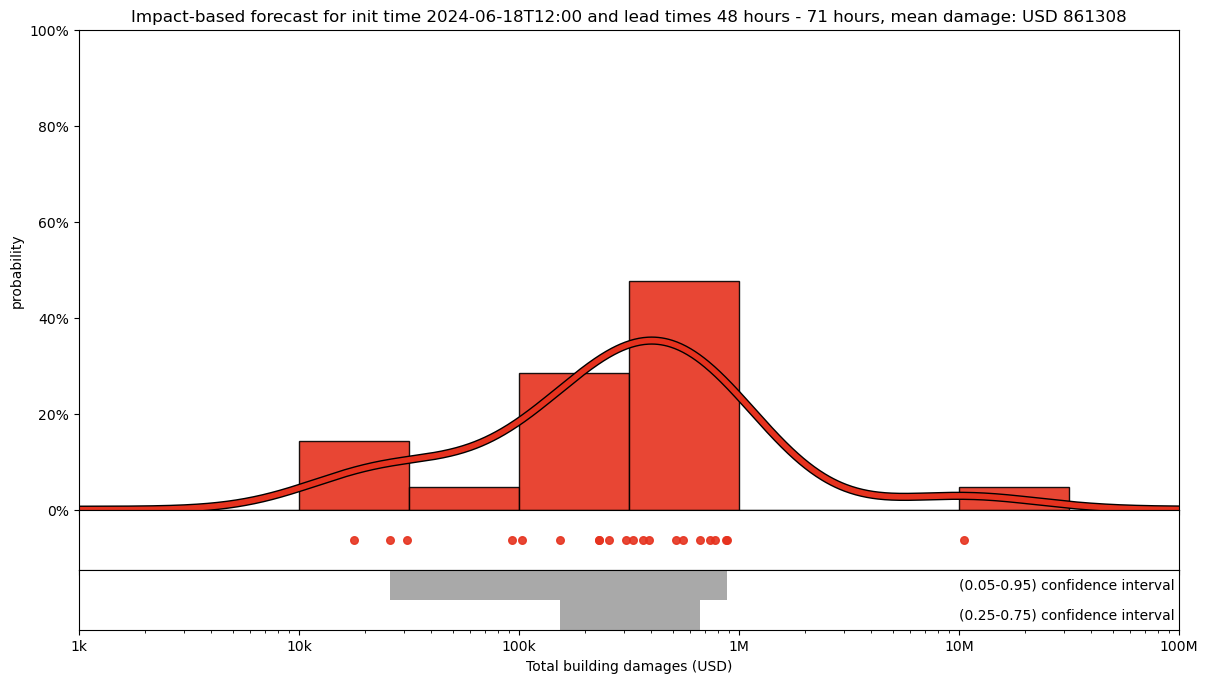

In [10]:
mean_impact = np.mean(imp_fc.at_event)

shift_bins = max(np.round(np.log10(np.mean(imp_fc.at_event))) - 3, 0)
bins = np.geomspace(10**shift_bins, 10 ** (5 + shift_bins), 11)

ax = plot_impact_log_hist(
    imp_fc,
    title=f"Impact-based forecast for init time {reference_time} and lead times {lead_times_window}, mean damage: USD {mean_impact:.0f}",
    impact_label="Total building damages (USD)",
    bins=bins,
    ticks=bins[::2],
)

# 4. Plot a regional pie-chart map

Next, we show how to aggregate the impact forecast over regions (in our case: cantons) and plot a pie chart per region, where the different pieces showcase the different members.

In [11]:
def plot_member_piechart_per_region(
    impact_forecast,
    gdf_regions,
    agg_func,
    bins=None,
    ax=None,
    exposure_for_normalization=None,
    pie_rel_size=0.1,
    title=None,
    cbar_title=None,
    cmap=None,
    shift_center_of_mass_by_name=None,
    kwargs_pie=None,
    **kwargs,
):
    """
    Plot pie charts for each region showing impact forecast member distributions.

    This function creates a map with pie charts centered in each region, where each pie
    represents the distribution of impact forecast members, optionally normalized by exposure.

    Parameters
    ----------
    impact_forecast : ImpactForecast
        The impact forecast object.
    gdf_regions : GeoDataFrame
        The geographical regions for plotting.
    agg_func : callable
        Aggregation function for impacts.
    bins : array-like, optional
        Bins for categorizing impact values (default auto-generated).
    ax : matplotlib Axes, optional
        Axes to plot on (default creates new figure).
    exposure_for_normalization : Exposure, optional
        Exposure data for normalizing impacts.
    pie_rel_size : float, optional
        Relative size of pie charts (default 0.1).
    title : str, optional
        Plot title.
    cbar_title : str, optional
        Colorbar title.
    cmap : matplotlib colormap, optional
        Colormap for pie colors (default 'Reds').
    shift_center_of_mass_by_name : dict, optional
        Dictionary to shift pie centers by region name.
    kwargs_pie : dict, optional
        Additional kwargs for pie charts.
    **kwargs : dict
        Additional plotting kwargs.

    Returns
    -------
    matplotlib Axes
        The axes object with the plot.
    """
    if cmap is None:
        cmap = plt.get_cmap("Reds")
    if kwargs_pie is None:
        kwargs_pie = {}
    kwargs_pie = {
        "startangle": 90,
        "wedgeprops": {"linewidth": 0.1, "edgecolor": "black", "alpha": 1.0},
    } | kwargs_pie
    if ax is not None and hasattr(ax, "projection"):
        current_crs = ax.projection
    else:
        current_crs = gdf_regions.crs

    if ax is None:
        ax = gdf_regions.geometry.plot(
            facecolor="white", edgecolor="black", figsize=kwargs.get("figsize", (10, 6))
        )
    else:
        gdf_regions.geometry.to_crs(current_crs).plot(
            ax=ax, facecolor="white", edgecolor="black"
        )
    bbox = (*ax.get_xlim(), *ax.get_ylim())

    gdf_impact_agg = aggregate_impacts_by_gdf(impact_forecast, gdf_regions, agg_func)
    gdf_impact_agg["centerofmass"] = gdf_impact_agg.geometry.to_crs(
        current_crs
    ).centroid
    if shift_center_of_mass_by_name is not None:
        for name, shift in shift_center_of_mass_by_name.items():
            gdf_impact_agg.loc[gdf_impact_agg["NAME"] == name, "centerofmass"] = (
                gdf_impact_agg.loc[
                    gdf_impact_agg["NAME"] == name, "centerofmass"
                ].apply(lambda g: translate(g, *shift))
            )

    if exposure_for_normalization is not None:
        agg_exp = aggregate_exposures_by_gdf(exposure_for_normalization, gdf_regions)
        if (
            gdf_impact_agg[list(impact_forecast.event_id)].shape[0]
            != agg_exp["value"].shape[0]
        ):
            raise ValueError(
                f"Number of columns of aggregated impact matrix "
                f"(shape {gdf_impact_agg[list(impact_forecast.event_id)].shape})"
                f"does not correspond to number of columns of aggregated exposure "
                f"({agg_exp['value'].shape[0]})."
            )
        gdf_impact_agg[list(impact_forecast.event_id)] = gdf_impact_agg[
            list(impact_forecast.event_id)
        ].div(agg_exp["value"], axis=0)

    max_values = gdf_impact_agg[list(impact_forecast.event_id)].values.max()
    if bins is None:
        bins = np.linspace(0, max_values, 5)
    pie_width = pie_rel_size * min(bbox[1] - bbox[0], bbox[3] - bbox[2])

    for idx, row in gdf_impact_agg.iterrows():
        x_loc, y_loc = row["centerofmass"].x, row["centerofmass"].y
        inset_ax = ax.inset_axes(
            [x_loc - pie_width / 2, y_loc - pie_width / 2, pie_width, pie_width],
            transform=ax.transData,
        )
        values = row[list(impact_forecast.event_id)].values
        indices = np.searchsorted(bins, np.sort(values))
        colors = cmap(indices / len(bins))
        inset_ax.pie(
            np.ones(len(impact_forecast.member)),
            labels=None,
            colors=colors,
            **kwargs_pie,
        )

    cbax = ax.inset_axes([1.05, 0, 0.05, 1])
    norm = mpl.colors.BoundaryNorm(bins, cmap.N, extend="both")
    cbar = ax.get_figure().colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbax, orientation="vertical"
    )
    cbar.set_label(cbar_title)
    ax.set_title(title)
    return ax

In [12]:
# prepare canton shapes
gdf_cantons = gpd.read_file(path_to_canton_shapes)
gdf_cantons = gdf_cantons.to_crs(epsg=4326)
gdf_cantons = gdf_cantons.dissolve(by="NAME", as_index=False)
gdf_cantons = gdf_cantons.loc[gdf_cantons.ICC == "CH", :].reset_index(drop=True)
gdf_cantons = gdf_cantons[["NAME", "geometry"]]
shift_center_of_mass_by_name = {
    "Basel-Landschaft": np.array([0.05, 0]),
    "Obwalden": np.array([-0.02, 0]),
    "Nidwalden": np.array([0, 0.01]),
    "St. Gallen": np.array([-0.15, -0.001]),
    "Appenzell Ausserrhoden": np.array([-0.02, 0.05]),
    "Appenzell Innerrhoden": np.array([0.03, -0.04]),
}

/var/folders/04/tbpkdd855mg6mjr2mj6h1csh0000gp/T/ipykernel_36524/3885012373.py:82: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ).centroid


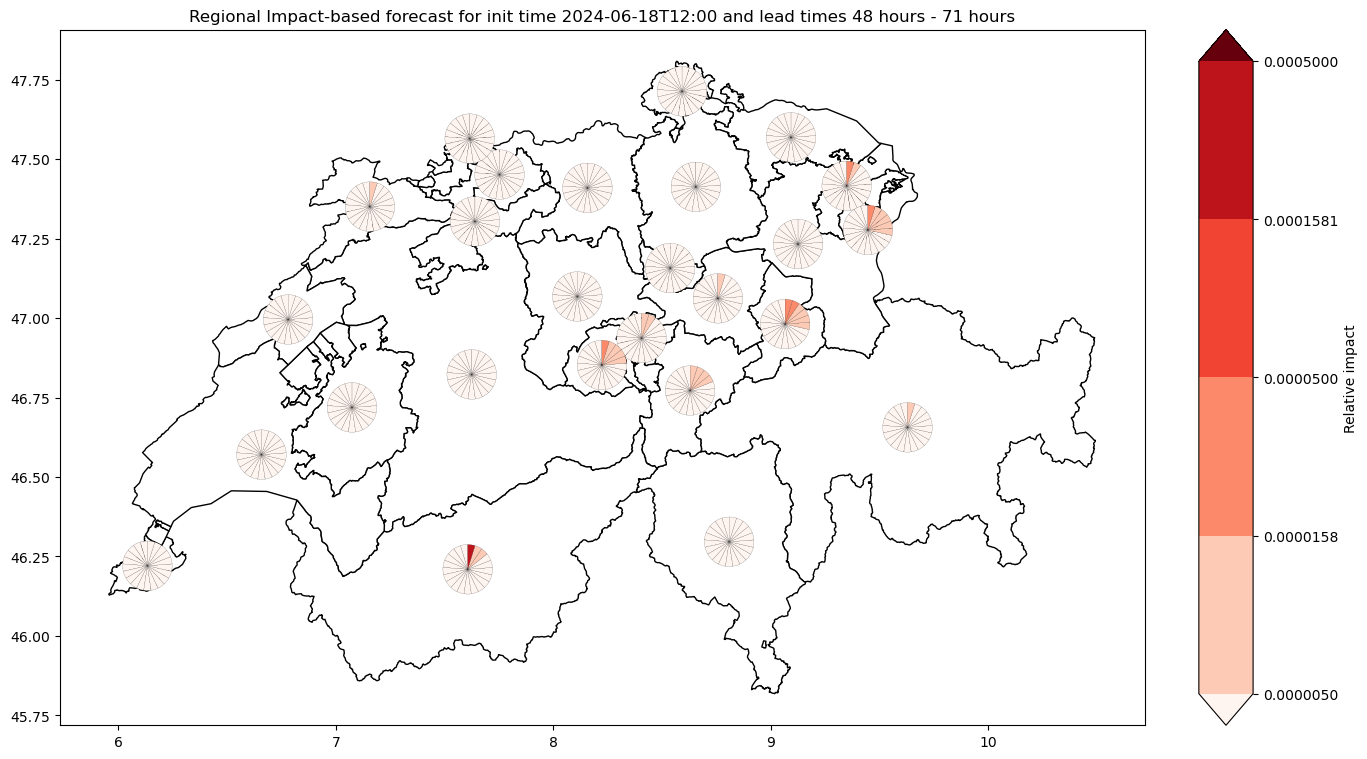

In [13]:
bins = np.geomspace(0.000005, 0.0005, 5)

init_time = reference_time

ax = plot_member_piechart_per_region(
    imp_fc,
    gdf_cantons,
    "sum",
    pie_rel_size=0.13,
    bins=bins,
    figsize=(14, 10),
    title=f"Regional Impact-based forecast for init time {init_time} and lead times {lead_times_window}",
    cbar_title="Relative impact",
    exposure_for_normalization=exp_ch,
    shift_center_of_mass_by_name=shift_center_of_mass_by_name,
)

# 5. Plot threshold-based warnings

Finally, we showcase an example how one can create a warning map based on thresholds (in this examples hazard threshold but impact threshold would also be possible).

The warning level is assigned by first computing the warning level per pixel and forecast member, and then computing the 90% quantile over the forecast members for each pixel. Finally, each warning region is assigned the median warning level of all pixels.

In [14]:
def plot_warning_polygons(
    imp_warnings,
    gdf_warningregions,
    agg_func="max",
    ax=None,
    title=None,
    warning_colors=None,
    warning_labels=None,
    kwargs_legend=None,
    **kwargs
):
    """
    Plot warning polygons based on impact thresholds.

    This function visualizes warning regions colored by aggregated impact levels,
    using a discrete colormap for hazard severity.

    Parameters
    ----------
    imp_warnings : ImpactWarnings
        The impact warnings object.
    gdf_warningregions : GeoDataFrame
        The warning regions GeoDataFrame.
    agg_func : str or callable, optional
        Aggregation function (default 'max').
    ax : matplotlib Axes, optional
        Axes to plot on (default creates new figure).
    title : str, optional
        Plot title (default auto-generated).
    warning_colors : array-like, optional
        RGBA colors for warning levels (default predefined).
    warning_labels : list, optional
        Labels for warning levels (default predefined).
    kwargs_legend : dict, optional
        Additional kwargs for legend.
    **kwargs : dict
        Additional plotting kwargs.

    Returns
    -------
    matplotlib Axes
        The axes object with the plot.
    """
    gdf_warnings = aggregate_impacts_by_gdf(
        imp_warnings, gdf_warningregions, agg_func=agg_func
    )
    figsize = kwargs.pop("figsize", (10, 6))
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    if warning_colors is None:
        warning_colors = (
            np.array(
                [
                    [204, 255, 102, 255],  # green
                    [255, 255, 0, 255],  # yellow
                    [255, 153, 0, 255],  # orange
                    [255, 0, 0, 255],  # red
                    [128, 0, 0, 255],  # dark red
                ]
            )
            / 255
        )
    if warning_labels is None:
        warning_labels = [
            "1: Minimal or no hazard",
            "2: Moderate hazard",
            "3: Significant hazard",
            "4: Severe hazard",
            "5: Very severe hazard",
        ]
    cmap = mpl.colors.ListedColormap(warning_colors)
    norm = mpl.colors.BoundaryNorm(np.arange(0.5, 6.5, 1), cmap.N)

    gdf_warnings.plot(
        column=1, cmap=cmap, norm=norm, edgecolor="black", linewidth=0.5, ax=ax
    )

    legend_elements = [
        mpl.patches.Patch(facecolor=color, edgecolor="k", label=label)
        for color, label in zip(warning_colors, warning_labels)
    ]
    if kwargs_legend is None:
        kwargs_legend = {}
    kwargs_legend = {
        "loc": "lower right",
        "framealpha": 0.5,
        "bbox_to_anchor": (1.100, -0.02),
    } | kwargs_legend
    ax.legend(handles=legend_elements, **kwargs_legend)
    if title is None:
        title = "Impact-threshold based warning per warning region"
    ax.set_title(title)
    return ax

In [15]:
# Prepare exposure including different warning thresholds pased on elevation
haz_fc.centroids.set_region_id()
constant_exposure_gdf = haz_fc.centroids.gdf
constant_exposure_gdf = constant_exposure_gdf.loc[
    constant_exposure_gdf["region_id"] == 756
]  # numeric iso of CH
constant_exposure_gdf.drop(columns="on_land", inplace=True)
constant_exposure_gdf["value"] = 1.0
constant_exposure_gdf["impf_"] = 1
elev = srtm.get_data()
constant_exposure_gdf["elevation"] = [
    elev.get_elevation(lat, lon)
    for lon, lat in zip(
        constant_exposure_gdf.geometry.x, constant_exposure_gdf.geometry.y
    )
]

constant_exposure = Exposures(constant_exposure_gdf)
# Locations points above 1600m elevation have different warning thresholds (encoded in the impact functions)
constant_exposure.data.loc[constant_exposure_gdf["elevation"] > 1600, "impf_"] = 2
constant_exposure.assign_centroids(haz_fc, threshold=100)

In [16]:
# Create impact functions corresponding to MeteoSwiss warning levels
imp_fun_low = ImpactFunc()
imp_fun_low.haz_type = "WS"
imp_fun_low.id = 1
imp_fun_low.name = "warn_level_low_elevation"
imp_fun_low.intensity_unit = "m/s"
imp_fun_low.intensity = np.array(
    [0.0, 19.439, 19.44, 24.999, 25.0, 30.549, 30.55, 38.879, 38.88, 100.0]
)
imp_fun_low.mdd = np.array([1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 4.0, 4.0, 5.0, 5.0])
imp_fun_low.paa = np.ones_like(imp_fun_low.mdd)
imp_fun_low.check()

imp_fun_high = ImpactFunc()
imp_fun_high.haz_type = "WS"
imp_fun_high.id = 2
imp_fun_high.name = "warn_level_high_elevation"
imp_fun_high.intensity_unit = "m/s"
imp_fun_high.intensity = np.array(
    [0.0, 27.776, 27.777, 36.110, 36.111, 44.443, 44.444, 55.554, 55.555, 100.0]
)
imp_fun_high.mdd = np.array([1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 4.0, 4.0, 5.0, 5.0])
imp_fun_high.paa = np.ones_like(imp_fun_high.mdd)

Hbw_impf_set = ImpactFuncSet([imp_fun_low, imp_fun_high])

In [17]:
# compute impacts
imp_warnings = (
    ImpactCalc(constant_exposure, Hbw_impf_set, haz_fc)
    .impact(assign_centroids=False)
    .quantile(q=.9)
)

2026-04-21 12:13:25,162 - climada.hazard.base - WARNING - Impact function id=1 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2026-04-21 12:13:25,172 - climada.hazard.base - WARNING - Impact function id=2 has mdr(0) != 0.The mean damage ratio must thus be computed for all values ofhazard intensity including 0 which can be very time consuming.
2026-04-21 12:13:25,185 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
2026-04-21 12:13:25,188 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2026-04-21 12:13:25,191 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure valu

In [18]:
gdf_warningregions = gpd.read_file(path_to_warningregion_shapes)
gdf_warningregions.crs = ccrs.epsg(21781)
gdf_warningregions = gdf_warningregions.dissolve(by="REGION_NAM", as_index=False)
gdf_warningregions = gdf_warningregions[["REGION_NAM", "geometry"]]
gdf_warningregions = gdf_warningregions.to_crs(epsg=4326)

<Axes: title={'center': 'Threshold-based wind warning for init time 2024-06-18T12:00 and lead times 48 hours - 71 hours'}>

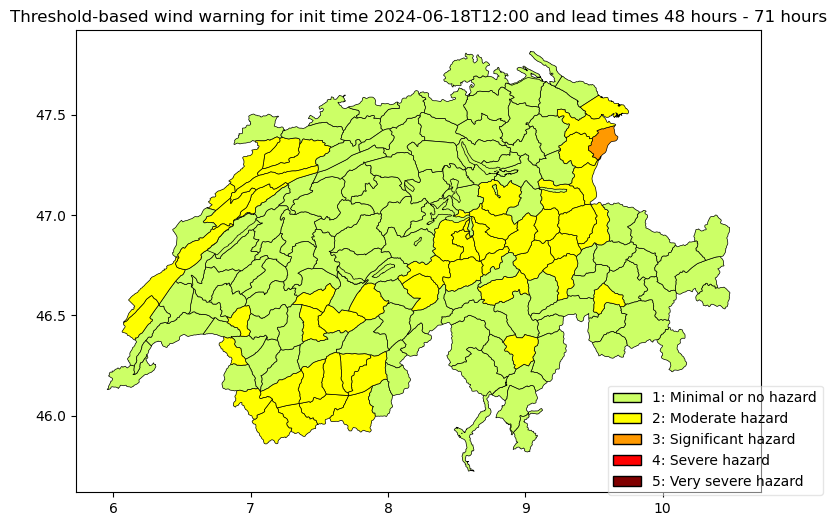

In [21]:
init_time = reference_time

plot_warning_polygons(
    imp_warnings,
    gdf_warningregions,
    agg_func="median",
    title=f"Threshold-based wind warning for init time {init_time} and lead times {lead_times_window}",
    figsize=(10, 6),
)